Feature Engineering and Regression Pipeline
Date Feature Engineering

In [2]:
import pandas as pd

df = pd.read_csv("q3_retail_promotion.csv")
df["transaction_date"] = pd.to_datetime(df["transaction_date"], errors="coerce")

df["year"] = df["transaction_date"].dt.year
df["month"] = df["transaction_date"].dt.month
df["day_of_week"] = df["transaction_date"].dt.dayofweek
df["is_month_end"] = (df["transaction_date"].dt.day >= 25).astype(int)

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


 Temporal Train-Test Split 

why random split is inappropriate
A random split is inappropriate for time-ordered data because it mixes past and future observations across train/test. This can cause data leakage, where the model indirectly “sees” patterns from the future during training, making evaluation metrics overly optimistic. A temporal split reflects real forecasting conditions: train on earlier periods, test on later unseen periods.

In [3]:
import numpy as np

df_sorted = df.sort_values("transaction_date").reset_index(drop=True)

cut = int(np.floor(len(df_sorted) * 0.8))
train_df = df_sorted.iloc[:cut].copy()
test_df  = df_sorted.iloc[cut:].copy()

X_train = train_df.drop(columns=["items_sold"])
y_train = train_df["items_sold"]

X_test  = test_df.drop(columns=["items_sold"])
y_test  = test_df["items_sold"]

Preprocessing Pipeline with ColumnTransformer

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Drop raw date column (we already engineered year/month/day_of_week/is_month_end)
X_train2 = X_train.drop(columns=["transaction_date"])
X_test2  = X_test.drop(columns=["transaction_date"])

categorical_features = ["promotion_type", "location_type", "store_size"]
numeric_features = [c for c in X_train2.columns if c not in categorical_features]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features),
    ],
    remainder="drop",
)

Model Training and Evaluation 

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Define Pipelines
# -----------------------------
lin_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))
])

# -----------------------------
# 2. Train Models
# -----------------------------
lin_pipe.fit(X_train2, y_train)
rf_pipe.fit(X_train2, y_train)

# -----------------------------
# 3. Predictions
# -----------------------------
lin_pred = lin_pipe.predict(X_test2)
rf_pred  = rf_pipe.predict(X_test2)

# -----------------------------
# 4. Evaluation 
# -----------------------------
lin_rmse = np.sqrt(mean_squared_error(y_test, lin_pred))
lin_mae  = mean_absolute_error(y_test, lin_pred)

rf_rmse  = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae   = mean_absolute_error(y_test, rf_pred)

# -----------------------------
# 5. Print Results
# -----------------------------
print(f"Linear Regression -> RMSE: {lin_rmse:.3f}, MAE: {lin_mae:.3f}")
print(f"Random Forest     -> RMSE: {rf_rmse:.3f}, MAE: {rf_mae:.3f}")

Linear Regression -> RMSE: 27.121, MAE: 21.053
Random Forest     -> RMSE: 30.787, MAE: 24.301


Parity Plot 

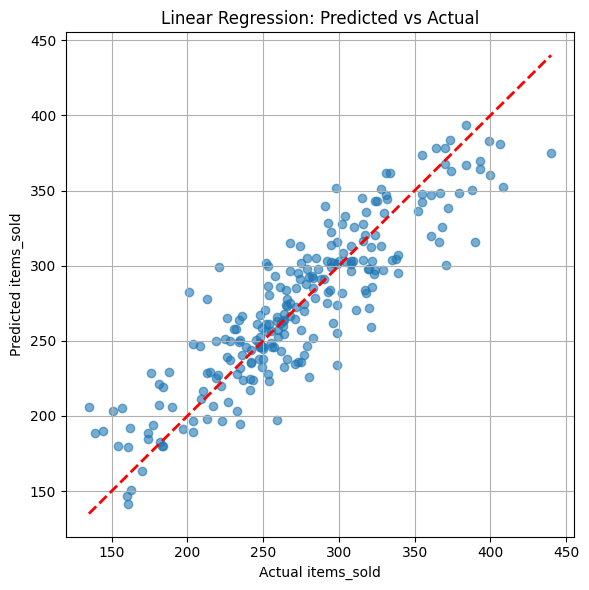

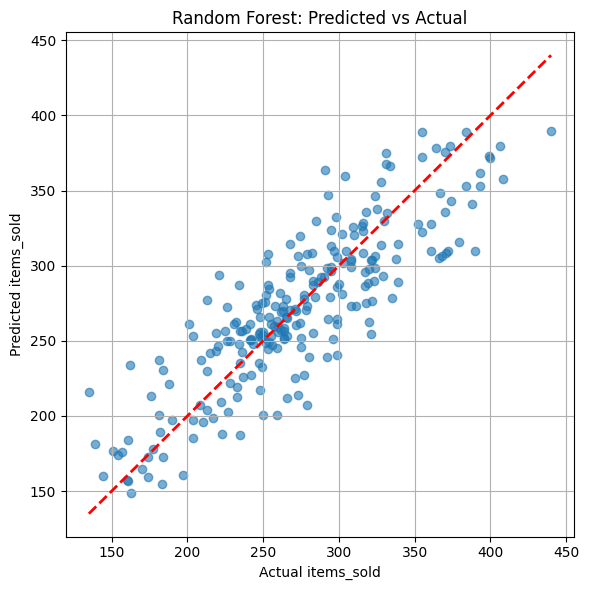

In [11]:
import matplotlib.pyplot as plt

def parity_plot(y_true, y_pred, title):
    plt.figure(figsize=(6, 6))
    
    # Scatter plot
    plt.scatter(y_true, y_pred, alpha=0.6)
    
    # Diagonal line (perfect prediction)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    
    # Labels and title
    plt.xlabel("Actual items_sold")
    plt.ylabel("Predicted items_sold")
    plt.title(title)
    
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Linear Regression parity plot
parity_plot(y_test, lin_pred, "Linear Regression: Predicted vs Actual")

# Random Forest parity plot
parity_plot(y_test, rf_pred, "Random Forest: Predicted vs Actual")


Random Forest Feature Importances + Top 5

In [12]:
import pandas as pd

preprocessor = rf_pipe.named_steps["preprocess"]
cat_ohe = preprocessor.named_transformers_["cat"]

cat_names = list(cat_ohe.get_feature_names_out(categorical_features))
feature_names = cat_names + numeric_features

importances = rf_pipe.named_steps["model"].feature_importances_

imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values(
    "importance", ascending=False
)

print("Top 5 most influential features:")
print(imp_df.head(5).to_string(index=False))

Top 5 most influential features:
            feature  importance
        is_festival    0.176912
   store_size_small    0.162806
location_type_urban    0.114856
        day_of_week    0.087888
         is_weekend    0.060840
